#Decision Tree Classifier on Iris Dataset
# Machine Learning Assignment

Import necessary libraries

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn import tree
import graphviz

Load the Iris dataset

In [9]:
print("Loading Iris Dataset...")
iris = load_iris()
X = iris.data  # Features: sepal length, sepal width, petal length, petal width
y = iris.target  # Target: species (0: setosa, 1: versicolor, 2: virginica)

Loading Iris Dataset...


Create a DataFrame for better visualization

In [10]:
iris_df = pd.DataFrame(X, columns=iris.feature_names)
iris_df['species'] = y
iris_df['species_name'] = iris_df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

print("Dataset Information:")
print(f"Shape of features: {X.shape}")
print(f"Shape of target: {y.shape}")
print(f"Feature names: {iris.feature_names}")
print(f"Target names: {iris.target_names}")
print("\nFirst 5 rows of the dataset:")
print(iris_df.head())

Dataset Information:
Shape of features: (150, 4)
Shape of target: (150,)
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']

First 5 rows of the dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species species_name  
0        0       setosa  
1        0       setosa  
2        0       setosa  
3        0       setosa  
4        0       setosa  


Exploratory Data Analysis

In [11]:
print("\n" + "="*50)
print("EXPLORATORY DATA ANALYSIS")
print("="*50)


EXPLORATORY DATA ANALYSIS


Basic statistics

In [12]:
print("\nDataset Statistics:")
print(iris_df.describe())


Dataset Statistics:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)     species  
count        150.000000  150.000000  
mean           1.199333    1.000000  
std            0.762238    0.819232  
min            0.100000    0.000000  
25%            0.300000    0.000000  
50%            1.300000    1.000000  
75%            1.800000    2.000000  
max            2.500000    2.000000  


Check for missing values

In [13]:
print(f"\nMissing values in dataset: {iris_df.isnull().sum().sum()}")




Missing values in dataset: 0


Visualize the dataset

In [14]:
plt.figure(figsize=(15, 10))

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

Subplot 1: Feature distribution by species

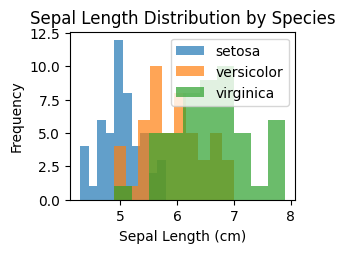

In [15]:
plt.subplot(2, 2, 1)
for species in range(3):
    species_data = iris_df[iris_df['species'] == species]
    plt.hist(species_data['sepal length (cm)'], alpha=0.7, label=iris.target_names[species])
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Frequency')
plt.title('Sepal Length Distribution by Species')
plt.legend()

Subplot 2: Scatter plot

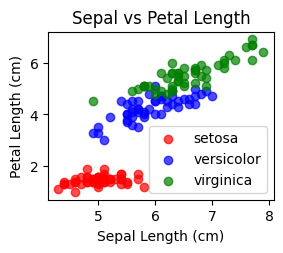

In [16]:
plt.subplot(2, 2, 2)
colors = ['red', 'blue', 'green']
for species in range(3):
    species_data = iris_df[iris_df['species'] == species]
    plt.scatter(species_data['sepal length (cm)'],
                species_data['petal length (cm)'],
                c=colors[species],
                label=iris.target_names[species],
                alpha=0.7)
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Petal Length (cm)')
plt.title('Sepal vs Petal Length')
plt.legend()

Subplot 3: Correlation heatmap

Text(0.5, 1.0, 'Feature Correlation Heatmap')

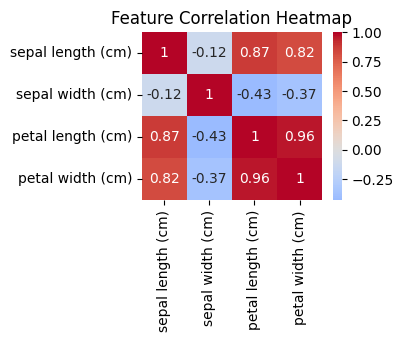

In [17]:
plt.subplot(2, 2, 3)
correlation_matrix = iris_df.iloc[:, :4].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')


Subplot 4: Box plot

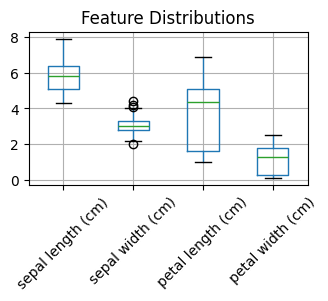

In [18]:
plt.subplot(2, 2, 4)
iris_df.boxplot(column=['sepal length (cm)', 'sepal width (cm)',
                        'petal length (cm)', 'petal width (cm)'])
plt.title('Feature Distributions')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

 Data Preprocessing

In [19]:
print("\n" + "="*50)
print("DATA PREPROCESSING")
print("="*50)


DATA PREPROCESSING


Split the dataset into training and testing sets

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"Number of features: {X_train.shape[1]}")

Training set size: 105 samples
Testing set size: 45 samples
Number of features: 4


Decision Tree Model

In [21]:
print("\n" + "="*50)
print("DECISION TREE CLASSIFIER")
print("="*50)



DECISION TREE CLASSIFIER


Create and train the Decision Tree classifier

In [22]:
dt_classifier = DecisionTreeClassifier(
    random_state=42,
    max_depth=3,  # Limiting depth for better visualization
    criterion='gini'  # We can also use 'entropy'
)

print("Training Decision Tree Classifier...")
dt_classifier.fit(X_train, y_train)

Training Decision Tree Classifier...


DecisionTreeClassifier(max_depth=3, random_state=42)

 Make predictions

In [44]:
y_pred = dt_classifier.predict(X_test)
y_pred_train = dt_classifier.predict(X_train)



Model Evaluation

In [45]:
print("\n" + "="*50)
print("MODEL EVALUATION")
print("="*50)


MODEL EVALUATION


Calculate accuracy

In [24]:
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred)

print(f"Training Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Testing Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

Training Accuracy: 0.9810 (98.10%)
Testing Accuracy: 0.9778 (97.78%)


Classification Report

In [25]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))


Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      0.93      0.97        15
   virginica       0.94      1.00      0.97        15

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



Confusion Matrix

In [26]:
print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

Confusion Matrix:
[[15  0  0]
 [ 0 14  1]
 [ 0  0 15]]


Visualize Confusion Matrix

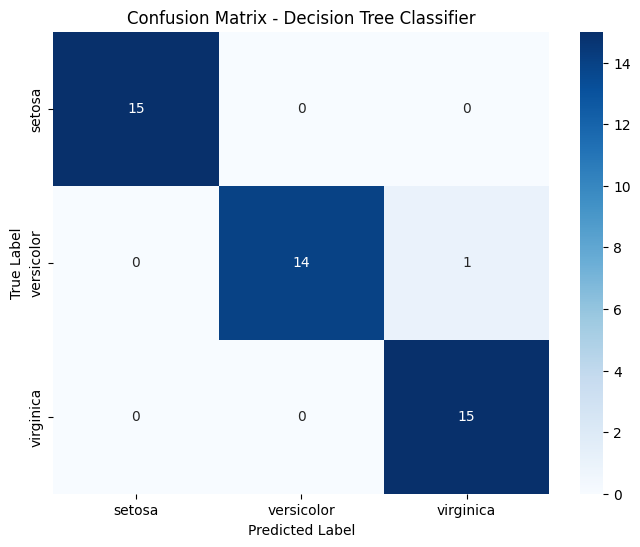

In [27]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.title('Confusion Matrix - Decision Tree Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Feature Importance

In [31]:
print("\n" + "="*50)
print("FEATURE IMPORTANCE")
print("="*50)

feature_importance = dt_classifier.feature_importances_
feature_names = iris.feature_names


FEATURE IMPORTANCE


Create a DataFrame for feature importance

In [46]:
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print("Feature Importance:")
print(importance_df)



Feature Importance:
             Feature  Importance
2  petal length (cm)    0.550877
3   petal width (cm)    0.449123
1   sepal width (cm)    0.000000
0  sepal length (cm)    0.000000


 Plot feature importance

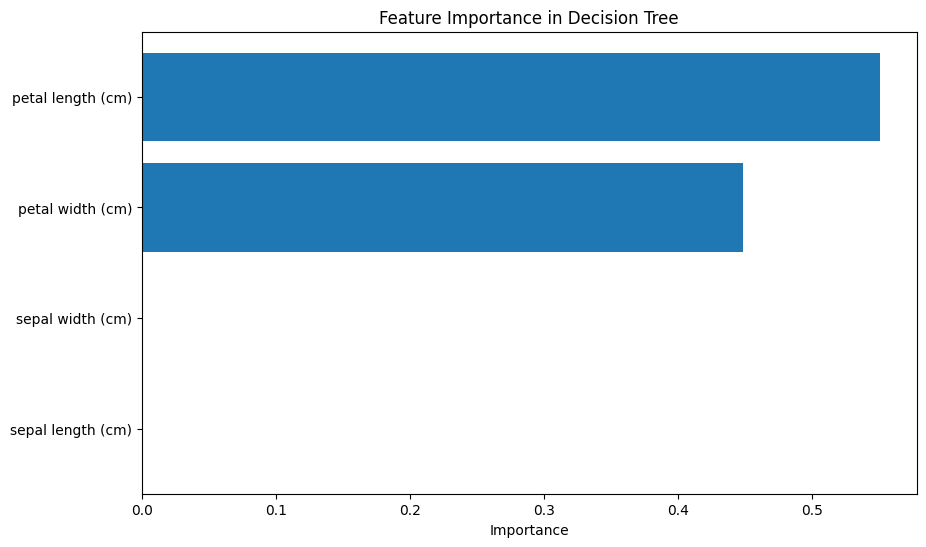

In [47]:
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Importance')
plt.title('Feature Importance in Decision Tree')
plt.gca().invert_yaxis()
plt.show()

Visualize the Decision Tree


DECISION TREE VISUALIZATION


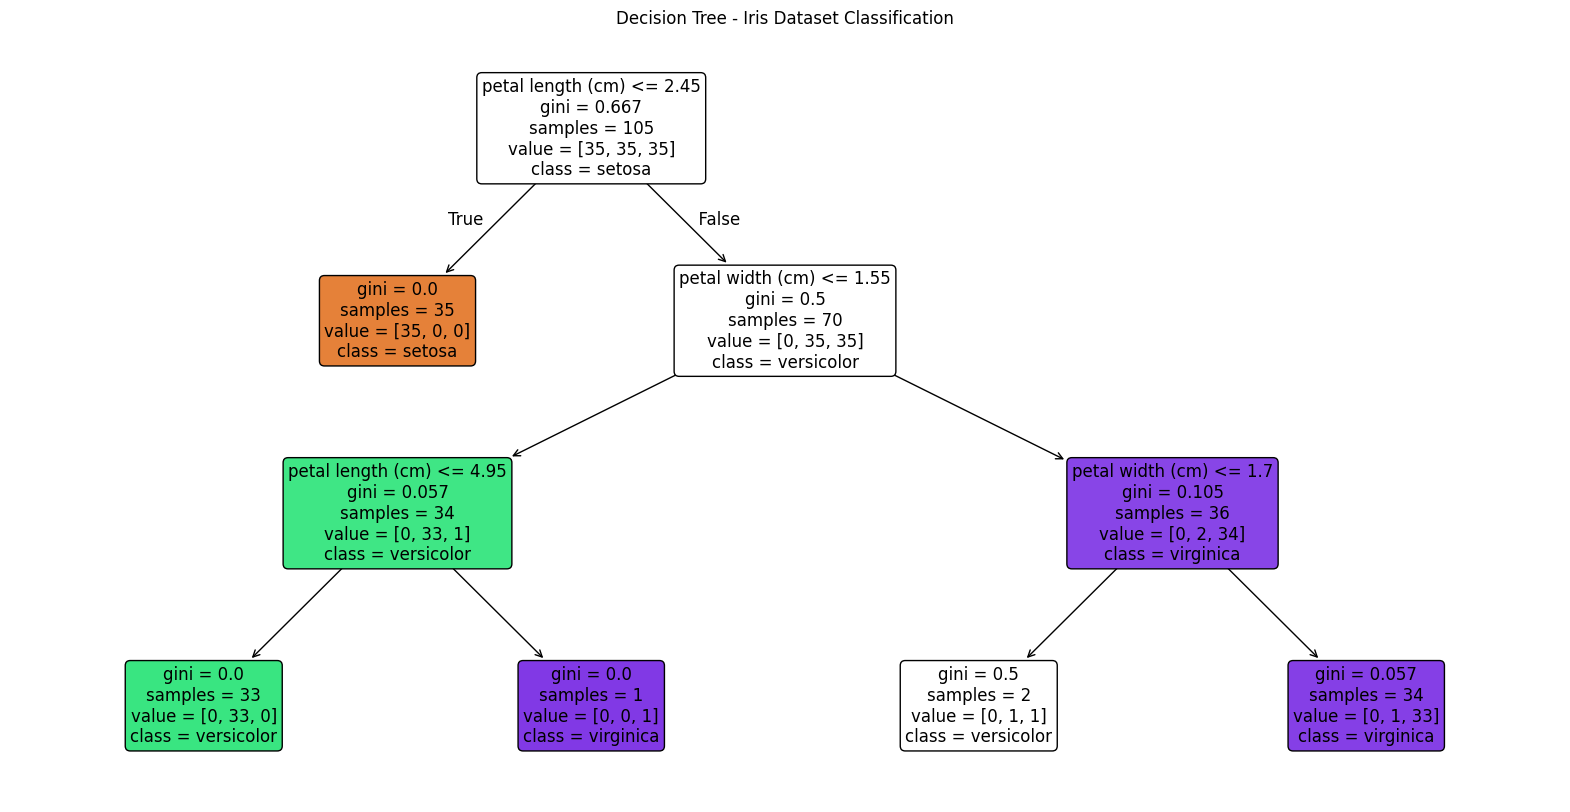

In [33]:
print("\n" + "="*50)
print("DECISION TREE VISUALIZATION")
print("="*50)

plt.figure(figsize=(20, 10))
plot_tree(dt_classifier,
          feature_names=iris.feature_names,
          class_names=iris.target_names,
          filled=True,
          rounded=True,
          fontsize=12)
plt.title('Decision Tree - Iris Dataset Classification')
plt.show()


Model Testing with Example Predictions

In [35]:
print("\n" + "="*50)
print("EXAMPLE PREDICTIONS")
print("="*50)


EXAMPLE PREDICTIONS


Create some test examples

In [39]:
test_examples = np.array([
    [5.1, 3.5, 1.4, 0.2],  # Should be setosa
    [6.0, 2.9, 4.5, 1.5],  # Should be versicolor
    [7.2, 3.0, 5.8, 2.1]   # Should be virginica
])
predictions = dt_classifier.predict(test_examples)
prediction_proba = dt_classifier.predict_proba(test_examples)


print("Test Predictions:")
for i, (example, pred, proba) in enumerate(zip(test_examples, predictions, prediction_proba)):
    print(f"Example {i+1}: {example}")
    print(f"Predicted: {iris.target_names[pred]}")
    print(f"Probabilities: {dict(zip(iris.target_names, proba))}")
    print("-" * 40)


Test Predictions:
Example 1: [5.1 3.5 1.4 0.2]
Predicted: setosa
Probabilities: {np.str_('setosa'): np.float64(1.0), np.str_('versicolor'): np.float64(0.0), np.str_('virginica'): np.float64(0.0)}
----------------------------------------
Example 2: [6.  2.9 4.5 1.5]
Predicted: versicolor
Probabilities: {np.str_('setosa'): np.float64(0.0), np.str_('versicolor'): np.float64(1.0), np.str_('virginica'): np.float64(0.0)}
----------------------------------------
Example 3: [7.2 3.  5.8 2.1]
Predicted: virginica
Probabilities: {np.str_('setosa'): np.float64(0.0), np.str_('versicolor'): np.float64(0.029411764705882353), np.str_('virginica'): np.float64(0.9705882352941176)}
----------------------------------------


Test different max_depth values

In [40]:
max_depths = range(1, 10)
train_scores = []
test_scores = []

for depth in max_depths:
    dt_temp = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt_temp.fit(X_train, y_train)
    train_scores.append(dt_temp.score(X_train, y_train))
    test_scores.append(dt_temp.score(X_test, y_test))

Plot learning curve

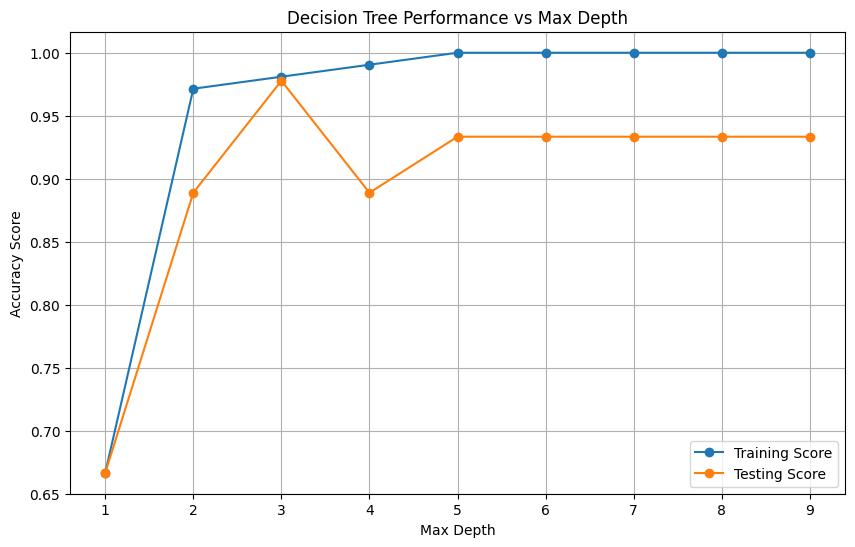


Assignment completed successfully!
Key Findings:
- Best test accuracy: 0.9778 at max_depth=3
- Most important feature: petal length (cm)
- The model shows good generalization performance


In [43]:
plt.figure(figsize=(10, 6))
plt.plot(max_depths, train_scores, 'o-', label='Training Score')
plt.plot(max_depths, test_scores, 'o-', label='Testing Score')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy Score')
plt.title('Decision Tree Performance vs Max Depth')
plt.legend()
plt.grid(True)
plt.show()

print("\nAssignment completed successfully!")
print("Key Findings:")
print(f"- Best test accuracy: {max(test_scores):.4f} at max_depth={max_depths[test_scores.index(max(test_scores))]}")
print(f"- Most important feature: {importance_df.iloc[0]['Feature']}")
print("- The model shows good generalization performance")
